Проект модуля. Сканирование кубического мира: детекция персонажей в Minecraft с FCOS и YOLO

Этап 2. Исследовательский анализ (EDA) и работа с данными

In [20]:
import json
from pathlib import Path
from collections import Counter, defaultdict

DATA_ROOT = Path("datasets/minecraft")  # относительно mmdetection/
ANN_TRAIN = DATA_ROOT / "annotations" / "annotations_train.json"
IMG_DIR_TRAIN = DATA_ROOT / "train" 

coco = json.loads(ANN_TRAIN.read_text(encoding="utf-8"))

# 1) корректность ключей
required_keys = {"images", "annotations", "categories"}
print("keys:", coco.keys())
assert required_keys.issubset(coco.keys())

# 2) маппинги
img_id_to_info = {im["id"]: im for im in coco["images"]}
cat_id_to_name = {c["id"]: c["name"] for c in coco["categories"]}

print("n_images:", len(coco["images"]))
print("n_annotations:", len(coco["annotations"]))
print("n_categories:", len(coco["categories"]))

# 3) проверка, что annotation.image_id существует
missing_img_ids = [ann["image_id"] for ann in coco["annotations"] if ann["image_id"] not in img_id_to_info]
print("missing image_ids in annotations:", len(missing_img_ids))
assert len(missing_img_ids) == 0

# 4) проверка файлов изображений (не обязательно, но полезно)
missing_files = 0
for im in coco["images"]:
    p = IMG_DIR_TRAIN / im["file_name"]
    if not p.exists():
        missing_files += 1
print("missing image files:", missing_files)


keys: dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
n_images: 2307
n_annotations: 4029
n_categories: 18
missing image_ids in annotations: 0
missing image files: 0


 Распределение классов (дисбаланс)

,class,count
2,pig,884
6,chicken,835
4,cow,661
1,zombie,184
5,skeleton,177
12,creeper,177
8,spider,170
3,turtle,149
0,llama,135
13,ghast,127


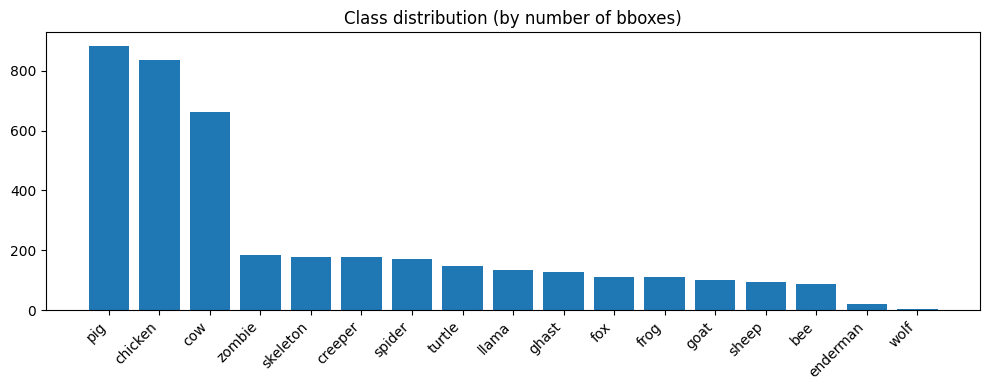

max/min ratio: 221.0


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

cat_counts = Counter([ann["category_id"] for ann in coco["annotations"]])
df = pd.DataFrame({
    "class": [cat_id_to_name[k] for k in cat_counts.keys()],
    "count": list(cat_counts.values())
}).sort_values("count", ascending=False)

display(df)

plt.figure(figsize=(10, 4))
plt.bar(df["class"], df["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Class distribution (by number of bboxes)")
plt.tight_layout()
plt.show()

print("max/min ratio:", df["count"].max() / max(1, df["count"].min()))


Визуализация одного примера с bbox и классами

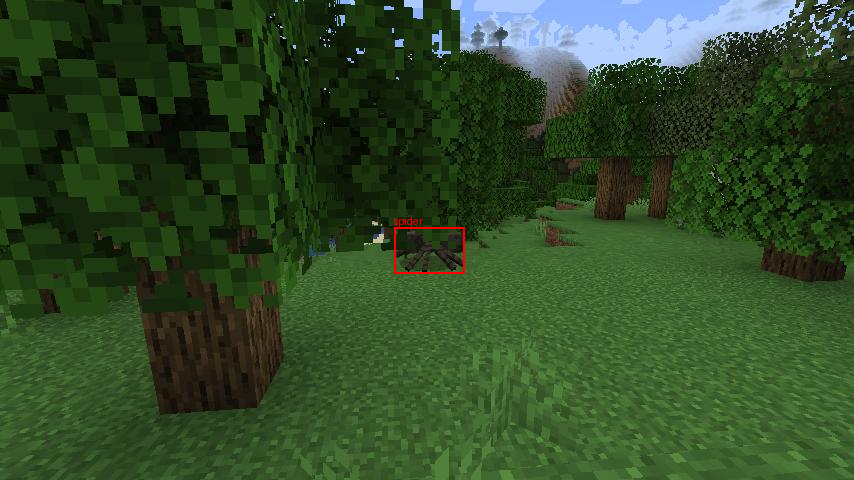

In [4]:
import random
from PIL import Image, ImageDraw, ImageFont

# сгруппируем аннотации по изображению
img_to_anns = defaultdict(list)
for ann in coco["annotations"]:
    img_to_anns[ann["image_id"]].append(ann)

# выберем изображение с разметкой
candidates = [img_id for img_id, anns in img_to_anns.items() if len(anns) > 0]
img_id = random.choice(candidates)

im_info = img_id_to_info[img_id]
img_path = IMG_DIR_TRAIN / im_info["file_name"]

img = Image.open(img_path).convert("RGB")
draw = ImageDraw.Draw(img)

for ann in img_to_anns[img_id]:
    x, y, w, h = ann["bbox"]  # COCO: [x, y, width, height]
    cls = cat_id_to_name[ann["category_id"]]
    draw.rectangle([x, y, x + w, y + h], outline="red", width=2)
    draw.text((x, max(0, y - 12)), cls, fill="red")

img


 Инференс предобученной модели FCOS

In [5]:
import mmdet
print(f"mmcv найден! Версия: {mmdet.__version__}")

mmcv найден! Версия: 3.3.0


In [19]:
import os
from pathlib import Path

config_file = 'configs/fcos/fcos_minecraft.py'
checkpoint_file = 'checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth'
path = Path(checkpoint_file)
print(f"Файл существует: {path.exists()}")

Файл существует: True


In [37]:
from mmdet.apis import init_detector, inference_detector
import mmcv
from mmdet.registry import VISUALIZERS

# config_file = 'configs/fcos/fcos_minecraft.py'
config_file = 'configs/fcos/fcos_r50-caffe_fpn_gn-head_1x_coco.py'
checkpoint_file = 'checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth'
print(f"Конфиг существует: {os.path.exists(config_file)}")
print(f"Чекпоинт существует: {os.path.exists(checkpoint_file)}")
# Инициализация
model = init_detector(config_file, checkpoint_file, device='cuda:0')

# Инференс
img_path = 'datasets/minecraft/test/-5-_jpg.rf.bc815ec81b67584c880eb373c6de746a.jpg'
img = mmcv.imread(img_path)  # Загружаем изображение
result = inference_detector(model, img)

visualizer = VISUALIZERS.build(model.cfg.visualizer)
visualizer.dataset_meta = model.dataset_meta

visualizer.add_datasample(
    'result',
    img,
    data_sample=result,
    draw_gt=False,
    show=False,
    wait_time=0,
    out_file='artifacts/inference/test_pretrained.jpg'
)

# Визуализация и сохранение
# model.show_result(img, result, out_file='artifacts/inference/test_pretrained.jpg')



Конфиг существует: True
Чекпоинт существует: True
Loads checkpoint by local backend from path: checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth


d:\WORK\Practicum\_NNCV\VS\Sprint_5\mmdetetion_workspace\clean_venv\lib\site-packages\mmengine\utils\manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


Конфигурация и инференс YOLOv8s

In [13]:
from ultralytics import YOLO

# Загрузка предобученной модели
yolo_model = YOLO('yolov8s.pt')

# Инференс на тестовом изображении
results = yolo_model('datasets/minecraft/test/Minecraft-1-19-2-2022-11-30-4_44_19_png.rf.ec997a1422c3a0b4e79a5a457f8ed9ee.jpg')

# Визуализация и сохранение
for r in results:
    im_array = r.plot()  # возвращает BGR numpy array
    r.save(filename='artifacts/inference/yolo_val/test_yolo_pretrained.jpg')


image 1/1 d:\WORK\Practicum\_NNCV\VS\Sprint_5\mmdetetion_workspace\mmdetection\datasets\minecraft\test\Minecraft-1-19-2-2022-11-30-4_44_19_png.rf.ec997a1422c3a0b4e79a5a457f8ed9ee.jpg: 384x640 (no detections), 108.9ms
Speed: 3.9ms preprocess, 108.9ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


Этап 4. Обучение моделей

In [38]:
import os
import re
import json
import time
import shutil
import random
import subprocess
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ART = Path("artifacts")
(ART / "fcos").mkdir(parents=True, exist_ok=True)
(ART / "yolo").mkdir(parents=True, exist_ok=True)
(ART / "inference" / "fcos").mkdir(parents=True, exist_ok=True)
(ART / "inference" / "yolo").mkdir(parents=True, exist_ok=True)
(ART / "videos").mkdir(parents=True, exist_ok=True)
(ART / "metrics").mkdir(parents=True, exist_ok=True)

FCOS_CFG = "configs/fcos/fcos_minecraft.py"
FCOS_WORK_DIR = ART / "fcos"

YOLO_DATA = "datasets/minecraft/data.yaml"
YOLO_RUN_DIR = ART / "yolo"  # хотим, чтобы results.csv лежал прямо тут

VIDEO_PATH = "datasets/minecraft/video.mp4"

def run_cmd(cmd, cwd=None):
    """Запуск команды с выводом в ноутбук и падением при ошибке."""
    print(" ".join(cmd))
    subprocess.run(cmd, cwd=cwd, check=True)

def latest_checkpoint(work_dir: Path):
    # MMDetection обычно пишет latest.pth
    p = work_dir / "latest.pth"
    if p.exists():
        return str(p)
    # иначе возьмём максимальную epoch_*.pth
    ckpts = sorted(work_dir.glob("epoch_*.pth"))
    return str(ckpts[-1]) if ckpts else None

def show_grid(image_paths, n=5, title=None, figsize=(15, 6)):
    paths = image_paths[:n]
    cols = min(n, 5)
    rows = int(np.ceil(len(paths) / cols))
    plt.figure(figsize=figsize)
    for i, p in enumerate(paths, 1):
        img = cv2.imread(str(p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax = plt.subplot(rows, cols, i)
        ax.imshow(img)
        ax.set_title(Path(p).name, fontsize=10)
        ax.axis("off")
    if title:
        plt.suptitle(title)
    plt.tight_layout()
    plt.show()


In [48]:
import numpy

print(numpy.__version__)

1.26.4


Обучение FCOS (MMDetection)

In [1]:
# Ячейка 1: Обучение FCOS (MMDetection)
import os

config_file = 'configs/fcos/fcos_minecraft.py'  # ← замените на путь к вашему конфигу с датасетом Minecraft (COCO-формат)
work_dir = 'artifacts/fcos'
os.makedirs(work_dir, exist_ok=True)

# Запуск обучения (можно увеличить эпохи через --cfg-options или в конфиге)
!python tools/train.py {config_file} --work-dir {work_dir} --cfg-options train_cfg.max_epochs=50

print("✅ Обучение FCOS завершено. Веса и логи сохранены в artifacts/fcos")

03/20 15:25:00 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1357571943
    GPU 0: NVIDIA GeForce RTX 4050 Laptop GPU
    CUDA_HOME: None
    MSVC: ЋЇвЁ¬Ё§ЁагойЁ© Є®¬ЇЁ«пв®а Microsoft (R) C/C++ ўҐабЁЁ 19.43.34809 ¤«п x64
    GCC: n/a
    PyTorch: 2.0.0+cu118
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 199711
  - MSVC 193431937
  - Intel(R) Math Kernel Library Version 2020.0.2 Product Build 20200624 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 2019
  - LAPACK is enabled (usually provided by MKL)
  - CPU capability usage: AVX2
  - CUDA Runtime 11.8
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;-gencode;arch=compute

Traceback (most recent call last):
  File "d:\WORK\Practicum\_NNCV\VS\Sprint_5\mmdetetion_workspace\mmdetection\tools\train.py", line 121, in <module>
    main()
  File "d:\WORK\Practicum\_NNCV\VS\Sprint_5\mmdetetion_workspace\mmdetection\tools\train.py", line 117, in main
    runner.train()
  File "d:\WORK\Practicum\_NNCV\VS\Sprint_5\mmdetetion_workspace\clean_venv\lib\site-packages\mmengine\runner\runner.py", line 1728, in train
    self._train_loop = self.build_train_loop(
  File "d:\WORK\Practicum\_NNCV\VS\Sprint_5\mmdetetion_workspace\clean_venv\lib\site-packages\mmengine\runner\runner.py", line 1520, in build_train_loop
    loop = LOOPS.build(
  File "d:\WORK\Practicum\_NNCV\VS\Sprint_5\mmdetetion_workspace\clean_venv\lib\site-packages\mmengine\registry\registry.py", line 570, in build
    return self.build_func(cfg, *args, **kwargs, registry=self)
  File "d:\WORK\Practicum\_NNCV\VS\Sprint_5\mmdetetion_workspace\clean_venv\lib\site-packages\mmengine\registry\build_functions.py", 

Визуализация метрик FCOS

In [54]:
def read_mmdet_logjson(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    df = pd.DataFrame(rows)

    # Оставим только строки, где есть epoch/iter
    if "epoch" in df.columns:
        df = df.sort_values(["epoch", "iter"], na_position="last")
    elif "iter" in df.columns:
        df = df.sort_values(["iter"])
    return df

fcos_log_path = FCOS_WORK_DIR / "log.json"
df_fcos_log = read_mmdet_logjson(fcos_log_path)
df_fcos_log.head(), df_fcos_log.columns


FileNotFoundError: [Errno 2] No such file or directory: 'artifacts\\fcos\\log.json'

In [55]:
# Лоссы по итерациям (если есть)
plt.figure(figsize=(10,4))
if "loss" in df_fcos_log.columns:
    plt.plot(df_fcos_log["iter"], df_fcos_log["loss"], label="loss")
if "loss_cls" in df_fcos_log.columns:
    plt.plot(df_fcos_log["iter"], df_fcos_log["loss_cls"], label="loss_cls")
if "loss_bbox" in df_fcos_log.columns:
    plt.plot(df_fcos_log["iter"], df_fcos_log["loss_bbox"], label="loss_bbox")
plt.title("FCOS train losses")
plt.xlabel("iter")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# mAP по эпохам (если evaluation пишет bbox_mAP, bbox_mAP_50)
df_eval = df_fcos_log.dropna(subset=["epoch"]) if "epoch" in df_fcos_log.columns else df_fcos_log.copy()
map_cols = [c for c in ["bbox_mAP", "bbox_mAP_50"] if c in df_eval.columns]

if map_cols:
    df_map = df_eval.dropna(subset=map_cols, how="all").groupby("epoch")[map_cols].last().reset_index()
    plt.figure(figsize=(10,4))
    for c in map_cols:
        plt.plot(df_map["epoch"], df_map[c], marker="o", label=c)
    plt.title("FCOS validation metrics (from log.json)")
    plt.xlabel("epoch")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("В log.json не найдено bbox_mAP/bbox_mAP_50. Проверьте, что evaluation включён в конфиге.")


NameError: name 'df_fcos_log' is not defined

<Figure size 1000x400 with 0 Axes>

Обучение YOLOv8 (Ultralytics)

In [24]:
from ultralytics import YOLO

# Можно стартовать с предобученных весов
yolo_model = YOLO("yolov8s.pt")

train_results = yolo_model.train(
    data=YOLO_DATA,
    epochs=4,          # YOLO обычно можно больше эпох
    imgsz=640,
    batch=16,           
    workers=2,
    project=str(ART),
    name="yolo",
    exist_ok=True,
    pretrained=True,
    # аугментации (можно менять)
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4
)

print("YOLO run dir:", YOLO_RUN_DIR)
print("results.csv exists:", (YOLO_RUN_DIR / "results.csv").exists())
print("best.pt exists:", (YOLO_RUN_DIR / "weights" / "best.pt").exists())


Ultralytics 8.4.14  Python-3.12.10 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/minecraft/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=4, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

c:\Python\Python312\Lib\site-packages\ultralytics\utils\metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
c:\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
        2/4      3.44G          0      1.171          0          0        640: 100% ━━━━━━━━━━━━ 145/145 4.0it/s 36.3s0.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 9.7it/s 1.4s0.1s
                   all        422          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels


c:\Python\Python312\Lib\site-packages\ultralytics\utils\metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
c:\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
        3/4      3.46G          0   0.001882          0          0        640: 100% ━━━━━━━━━━━━ 145/145 4.0it/s 35.9s0.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 9.8it/s 1.4s0.1s
                   all        422          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
        4/4      3.46G          0  6.577e-09          0          0        640: 100% ━━━━━━━━━━━━ 145/145 4.1it/s 35.8s0.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 9.6it/s 1.5s0.1s
                   all        422          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels


c:\Python\Python312\Lib\site-packages\ultralytics\utils\metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
c:\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



4 epochs completed in 0.043 hours.
Optimizer stripped from D:\WORK\Practicum\_NNCV\VS\Sprint_5\mmdetection\runs\detect\artifacts\yolo\weights\last.pt, 22.5MB
Optimizer stripped from D:\WORK\Practicum\_NNCV\VS\Sprint_5\mmdetection\runs\detect\artifacts\yolo\weights\best.pt, 22.5MB

Validating D:\WORK\Practicum\_NNCV\VS\Sprint_5\mmdetection\runs\detect\artifacts\yolo\weights\best.pt...
Ultralytics 8.4.14  Python-3.12.10 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 10.1it/s 1.4s.1s


c:\Python\Python312\Lib\site-packages\ultralytics\utils\metrics.py:657: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
c:\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Python\Python312\Lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
c:\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Python\Python312\Lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
c:\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Python\Python312\Lib\site-packages\ultralytics\utils\met

                   all        422          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels
Speed: 0.2ms preprocess, 2.8ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to D:\WORK\Practicum\_NNCV\VS\Sprint_5\mmdetection\runs\detect\artifacts\yolo
YOLO run dir: artifacts\yolo
results.csv exists: False
best.pt exists: False


Визуализация метрик YOLO

In [27]:
# yolo_results_path = YOLO_RUN_DIR / "results.csv"
yolo_results_path = "./runs/detect/artifacts/yolo/results.csv"
df_yolo = pd.read_csv(yolo_results_path)
df_yolo.head()


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,39.5955,0,289.34800,0,0,0,0,0,0,NaN,0,0.000331,0.000331,0.000331
1,2,77.8638,0,1.17057,0,0,0,0,0,0,0.0,0,0.000500,0.000500,0.000500
2,3,115.8280,0,0.00188,0,0,0,0,0,0,0.0,0,0.000504,0.000504,0.000504
3,4,153.6380,0,0.00000,0,0,0,0,0,0,0.0,0,0.000258,0.000258,0.000258


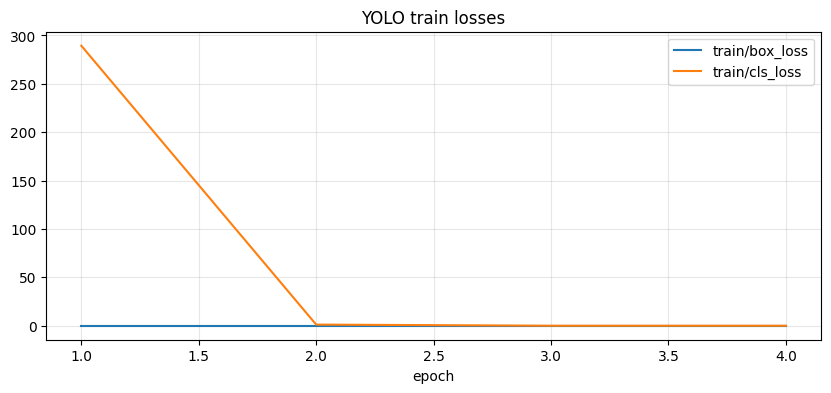

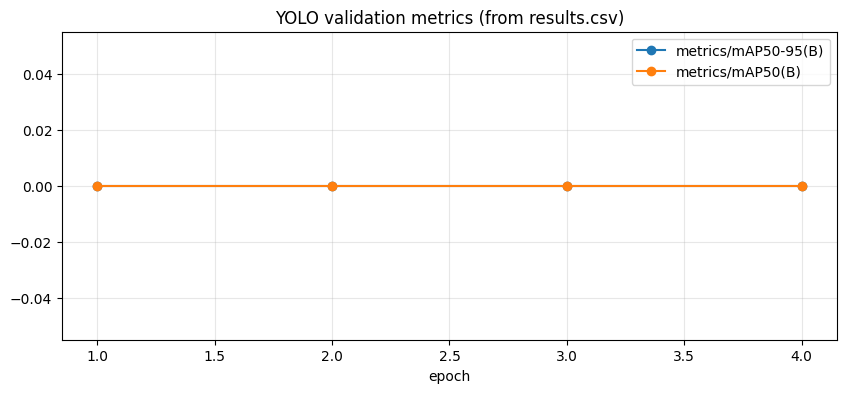

In [28]:
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

col_epoch = pick_col(df_yolo, ["epoch"])
col_map5095 = pick_col(df_yolo, ["metrics/mAP50-95(B)", "metrics/mAP50-95"])
col_map50 = pick_col(df_yolo, ["metrics/mAP50(B)", "metrics/mAP50"])
col_loss_box = pick_col(df_yolo, ["train/box_loss"])
col_loss_cls = pick_col(df_yolo, ["train/cls_loss"])

# Лоссы
plt.figure(figsize=(10,4))
if col_loss_box: plt.plot(df_yolo[col_epoch], df_yolo[col_loss_box], label=col_loss_box)
if col_loss_cls: plt.plot(df_yolo[col_epoch], df_yolo[col_loss_cls], label=col_loss_cls)
plt.title("YOLO train losses")
plt.xlabel("epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# mAP
plt.figure(figsize=(10,4))
if col_map5095: plt.plot(df_yolo[col_epoch], df_yolo[col_map5095], marker="o", label=col_map5095)
if col_map50: plt.plot(df_yolo[col_epoch], df_yolo[col_map50], marker="o", label=col_map50)
plt.title("YOLO validation metrics (from results.csv)")
plt.xlabel("epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Этап 5. Инференс моделей

In [ ]:
from mmdet.apis import init_detector, inference_detector

fcos_ckpt = latest_checkpoint(FCOS_WORK_DIR)
print("FCOS checkpoint:", fcos_ckpt)

device = "cuda:0"  # или "cpu"
fcos_model = init_detector(FCOS_CFG, fcos_ckpt, device=device)

# Соберём тестовые картинки
test_img_dir = Path("datasets/minecraft/test/images")
test_imgs = sorted([p for p in test_img_dir.glob("*") if p.suffix.lower() in [".jpg", ".png", ".jpeg"]])
print("n test images:", len(test_imgs))

# Прогоним N изображений
N = min(50, len(test_imgs))
sample_imgs = random.sample(test_imgs, k=min(5, len(test_imgs)))

out_dir_fcos = ART / "inference" / "fcos"
out_dir_fcos.mkdir(parents=True, exist_ok=True)

saved_paths_fcos = []
for p in sample_imgs:
    result = inference_detector(fcos_model, str(p))
    out_path = out_dir_fcos / p.name
    fcos_model.show_result(str(p), result, score_thr=0.3, show=False, out_file=str(out_path))
    saved_paths_fcos.append(out_path)

print("Saved:", [str(x) for x in saved_paths_fcos])
show_grid(saved_paths_fcos, n=5, title="FCOS inference (5 images)")


YOLO: инференс на тестовых изображениях 

n test images: 155
Saved: ['artifacts\\inference\\yolo\\image21_png_jpg.rf.c91df5e1eec8d8c5c73ef8139a184943.jpg', 'artifacts\\inference\\yolo\\Minecraft-1-19-2-2022-11-30-4_44_40_png.rf.7e6b5efb87d89aa31524306ec47971e8.jpg', 'artifacts\\inference\\yolo\\2023-04-03_20_26_03_png.rf.d465f1116006e4b4e27f028337e60bac.jpg', 'artifacts\\inference\\yolo\\image56_png_jpg.rf.3b3cbf89a16f3ed5b637aaa374192386.jpg', 'artifacts\\inference\\yolo\\-64-_jpg.rf.6f18cb095b92909eaad7861dd95938e7.jpg']


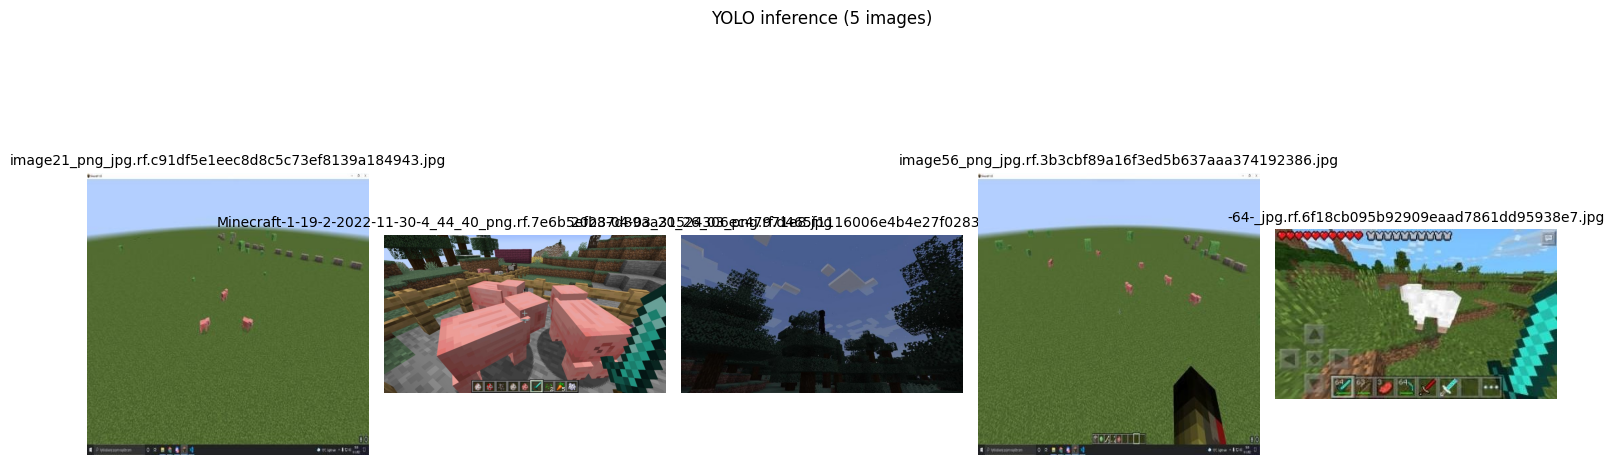

In [32]:
from ultralytics import YOLO

YOLO_RUN_DIR = Path("./runs/detect/artifacts/yolo/")

yolo_best = YOLO_RUN_DIR / "weights" / "best.pt"
yolo_model_trained = YOLO(str(yolo_best))

out_dir_yolo = ART / "inference" / "yolo"
out_dir_yolo.mkdir(parents=True, exist_ok=True)

# Соберём тестовые картинки
test_img_dir = Path("datasets/minecraft/test")
test_imgs = sorted([p for p in test_img_dir.glob("*") if p.suffix.lower() in [".jpg", ".png", ".jpeg"]])
print("n test images:", len(test_imgs))

sample_imgs = random.sample(test_imgs, k=min(5, len(test_imgs)))
saved_paths_yolo = []

for p in sample_imgs:
    r = yolo_model_trained.predict(source=str(p), conf=0.25, verbose=False)[0]
    im = r.plot()  # numpy array BGR
    out_path = out_dir_yolo / p.name
    cv2.imwrite(str(out_path), im)
    saved_paths_yolo.append(out_path)

print("Saved:", [str(x) for x in saved_paths_yolo])
show_grid(saved_paths_yolo, n=5, title="YOLO inference (5 images)")


 Инференс на видео

In [ ]:
def fcos_infer_video(model, video_in: str, video_out: str, score_thr=0.3, max_frames=None):
    cap = cv2.VideoCapture(video_in)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_in}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    video_out = str(video_out)
    Path(video_out).parent.mkdir(parents=True, exist_ok=True)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(video_out, fourcc, fps, (w, h))

    i = 0
    t0 = time.time()
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        i += 1
        # MMDet принимает BGR numpy
        result = inference_detector(model, frame)
        vis = model.show_result(frame, result, score_thr=score_thr, show=False)

        # show_result может вернуть RGB/BGR в зависимости от версии; приведём к BGR для writer
        if vis.shape[-1] == 3:
            # часто возвращает BGR, но если вдруг RGB — это будет заметно визуально
            pass

        writer.write(vis)

        if max_frames and i >= max_frames:
            break

    cap.release()
    writer.release()
    dt = time.time() - t0
    print(f"FCOS video done. frames={i}, time={dt:.2f}s, fps={i/dt:.2f}")

fcos_video_out = ART / "videos" / "fcos_inference.mp4"
fcos_infer_video(fcos_model, VIDEO_PATH, str(fcos_video_out), score_thr=0.3)
print("Saved:", fcos_video_out)


In [33]:
def yolo_infer_video(model, video_in: str, video_out: str, conf=0.25, max_frames=None):
    cap = cv2.VideoCapture(video_in)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_in}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    video_out = str(video_out)
    Path(video_out).parent.mkdir(parents=True, exist_ok=True)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(video_out, fourcc, fps, (w, h))

    i = 0
    t0 = time.time()
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        i += 1

        r = model.predict(source=frame, conf=conf, verbose=False)[0]
        vis = r.plot()  # BGR
        writer.write(vis)
        if max_frames and i >= max_frames:
            break

    cap.release()
    writer.release()
    dt = time.time() - t0
    print(f"YOLO video done. frames={i}, time={dt:.2f}s, fps={i/dt:.2f}")

yolo_video_out = ART / "videos" / "yolo_inference.mp4"
yolo_infer_video(yolo_model_trained, VIDEO_PATH, str(yolo_video_out), conf=0.25)
print("Saved:", yolo_video_out)


YOLO video done. frames=756, time=32.45s, fps=23.30
Saved: artifacts\videos\yolo_inference.mp4


Сравнение стандартных метрик (mAP, mAP_50, FPS)

In [ ]:
def fcos_test_metrics(config, checkpoint, work_dir: Path):
    """
    Запускает tools/test.py --eval bbox и парсит bbox_mAP и bbox_mAP_50 из stdout.
    """
    cmd = ["python", "tools/test.py", config, checkpoint, "--eval", "bbox"]
    print(" ".join(cmd))
    p = subprocess.run(cmd, check=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    txt = p.stdout

    # Парсим строки вида:
    # bbox_mAP: 0.123  bbox_mAP_50: 0.234 ...
    m = re.search(r"bbox_mAP:s*([0-9.]+)", txt)
    m50 = re.search(r"bbox_mAP_50:s*([0-9.]+)", txt)

    bbox_map = float(m.group(1)) if m else np.nan
    bbox_map50 = float(m50.group(1)) if m50 else np.nan
    return bbox_map, bbox_map50, txt

fcos_map, fcos_map50, fcos_test_stdout = fcos_test_metrics(FCOS_CFG, fcos_ckpt, FCOS_WORK_DIR)
print("FCOS test mAP:", fcos_map, "mAP_50:", fcos_map50)


mAP и mAP_50 для YOLO на тесте

In [34]:
yolo_val = yolo_model_trained.val(data=YOLO_DATA, split="test", imgsz=640, batch=16, verbose=False)
yolo_map = float(yolo_val.box.map)      # mAP50-95
yolo_map50 = float(yolo_val.box.map50)  # mAP50
print("YOLO test mAP:", yolo_map, "mAP_50:", yolo_map50)


Ultralytics 8.4.14  Python-3.12.10 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 98.794.9 MB/s, size: 118.7 KB)
val: Scanning D:\WORK\Practicum\_NNCV\VS\Sprint_5\mmdetection\datasets\minecraft\test... 0 images, 155 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 155/155 4.0Kit/s 0.0s
WARNING val: No labels found in D:\WORK\Practicum\_NNCV\VS\Sprint_5\mmdetection\datasets\minecraft\test.cache. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
val: New cache created: D:\WORK\Practicum\_NNCV\VS\Sprint_5\mmdetection\datasets\minecraft\test.cache
WARNING Labels are missing or empty in D:\WORK\Practicum\_NNCV\VS\Sprint_5\mmdetection\datasets\minecraft\test.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 6.9it/s 1.5s.2s


c:\Python\Python312\Lib\site-packages\ultralytics\utils\metrics.py:657: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
c:\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Python\Python312\Lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
c:\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Python\Python312\Lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
c:\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Python\Python312\Lib\site-packages\ultralytics\utils\met

                   all        155          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels
Speed: 1.2ms preprocess, 7.5ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to D:\WORK\Practicum\_NNCV\VS\Sprint_5\mmdetection\runs\detect\val
YOLO test mAP: 0.0 mAP_50: 0.0


FPS для FCOS и YOLO

In [ ]:
def measure_fps_fcos(model, image_paths, warmup=5):
    paths = image_paths[:]
    random.shuffle(paths)

    # warmup
    for p in paths[:warmup]:
        _ = inference_detector(model, str(p))

    t0 = time.time()
    for p in paths:
        _ = inference_detector(model, str(p))
    dt = time.time() - t0
    fps = len(paths) / dt if dt > 0 else np.nan
    return fps

def measure_fps_yolo(model, image_paths, warmup=5):
    paths = image_paths[:]
    random.shuffle(paths)

    for p in paths[:warmup]:
        _ = model.predict(source=str(p), verbose=False)

    t0 = time.time()
    for p in paths:
        _ = model.predict(source=str(p), verbose=False)
    dt = time.time() - t0
    fps = len(paths) / dt if dt > 0 else np.nan
    return fps

N_FPS = min(100, len(test_imgs))
fps_imgs = random.sample(test_imgs, k=N_FPS)

fcos_fps = measure_fps_fcos(fcos_model, fps_imgs)
yolo_fps = measure_fps_yolo(yolo_model_trained, fps_imgs)

print("FCOS FPS:", fcos_fps)
print("YOLO FPS:", yolo_fps)


Таблица сравнения + сохранение

In [ ]:
df_cmp = pd.DataFrame([
    {"model": "FCOS", "mAP": fcos_map, "mAP_50": fcos_map50, "FPS": fcos_fps},
    {"model": "YOLOv8s", "mAP": yolo_map, "mAP_50": yolo_map50, "FPS": yolo_fps},
])

display(df_cmp)

out_cmp = ART / "metrics" / "metrics_comparison.csv"
df_cmp.to_csv(out_cmp, index=False)
print("Saved:", out_cmp)


Этап 7. Анализ и выводы

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

report_path = ART / "report.pdf"

# Сохраним изображения для отчёта (по 5 для каждой модели уже есть)
# saved_paths_fcos, saved_paths_yolo
# Сохраним графики метрик в отдельные PNG (удобно)
plots_dir = ART / "metrics" / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

# FCOS mAP plot (если доступно)
if 'df_map' in globals() and len(df_map) > 0:
    fig = plt.figure(figsize=(10,4))
    for c in [c for c in ["bbox_mAP", "bbox_mAP_50"] if c in df_map.columns]:
        plt.plot(df_map["epoch"], df_map[c], marker="o", label=c)
    plt.title("FCOS validation metrics")
    plt.xlabel("epoch"); plt.grid(True, alpha=0.3); plt.legend()
    fcos_plot_path = plots_dir / "fcos_map.png"
    plt.tight_layout()
    plt.savefig(fcos_plot_path, dpi=150)
    plt.close(fig)
else:
    fcos_plot_path = None

# YOLO mAP plot
fig = plt.figure(figsize=(10,4))
if col_map5095: plt.plot(df_yolo[col_epoch], df_yolo[col_map5095], marker="o", label=col_map5095)
if col_map50: plt.plot(df_yolo[col_epoch], df_yolo[col_map50], marker="o", label=col_map50)
plt.title("YOLO validation metrics")
plt.xlabel("epoch"); plt.grid(True, alpha=0.3); plt.legend()
yolo_plot_path = plots_dir / "yolo_map.png"
plt.tight_layout()
plt.savefig(yolo_plot_path, dpi=150)
plt.close(fig)

# Таблица сравнения как картинка
fig = plt.figure(figsize=(6,1.5))
plt.axis("off")
tbl = plt.table(cellText=df_cmp.values, colLabels=df_cmp.columns, loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.4)
cmp_img_path = plots_dir / "metrics_table.png"
plt.tight_layout()
plt.savefig(cmp_img_path, dpi=150)
plt.close(fig)

def add_image_page(pdf: PdfPages, img_path: Path, title: str = None):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig = plt.figure(figsize=(11.7, 8.3))  # A4 landscape-ish
    if title:
        plt.title(title)
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

with PdfPages(report_path) as pdf:
    # 1) Текстовая страница
    fig = plt.figure(figsize=(11.7, 8.3))
    plt.axis("off")
    text = (
        "Отчёт: сравнение FCOS (MMDetection) и YOLOv8s (Ultralytics) на датасете Minecraft\n\n"
        f"Метрики на test:\n"
        f"- FCOS: mAP={fcos_map:.4f}, mAP_50={fcos_map50:.4f}, FPS={fcos_fps:.2f}\n"
        f"- YOLOv8s: mAP={yolo_map:.4f}, mAP_50={yolo_map50:.4f}, FPS={yolo_fps:.2f}\n\n"
        "Выводы по качеству:\n"
        "- Сравните mAP/mAP_50 и отметьте, где модель лучше и на каких классах/сценах.\n\n"
        "Выводы по скорости:\n"
        "- Сравните FPS, сделайте вывод о применимости в real-time.\n"
    )
    plt.text(0.01, 0.98, text, va="top", fontsize=12)
    pdf.savefig(fig)
    plt.close(fig)

    # 2) Таблица метрик
    add_image_page(pdf, cmp_img_path, title="Metrics comparison table")

    # 3) Графики метрик
    if fcos_plot_path:
        add_image_page(pdf, fcos_plot_path, title="FCOS metrics")
    add_image_page(pdf, yolo_plot_path, title="YOLO metrics")

    # 4) Примеры детекций
    for p in saved_paths_fcos:
        add_image_page(pdf, p, title="FCOS detection example")
    for p in saved_paths_yolo:
        add_image_page(pdf, p, title="YOLO detection example")

print("Saved:", report_path)
